# Healthcare-Style Speech Evaluatio

# 1 Overview

## 2 Import Libraries

In [19]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

## 3 Load Solace Pipeline

In [20]:
PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ai.multimodal_pipeline import MultimodalPipeline

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project


## 4 Load the 4 Recordings

In [21]:
pipeline = MultimodalPipeline()

print("Solace pipeline loaded.")

Solace pipeline loaded.


In [22]:
HEALTHCARE_FOLDER = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "healthcare_speech"
)

healthcare_clips = sorted(
    HEALTHCARE_FOLDER.glob("*.mp4")
)

print("Folder:", HEALTHCARE_FOLDER)
print("Number of recordings:", len(healthcare_clips))

for clip in healthcare_clips:
    print(clip.name)

Folder: c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\data\raw\healthcare_speech
Number of recordings: 12
healthcare01.mp4
healthcare02.mp4
healthcare03.mp4
healthcare04.mp4
healthcare05.mp4
healthcare06.mp4
healthcare07.mp4
healthcare08.mp4
healthcare09.mp4
healthcare10.mp4
healthcare11.mp4
healthcare12.mp4


## 5 Healthcare-Style Speech Evaluation

In [23]:
labels_df = pd.read_csv(
    HEALTHCARE_FOLDER
    / "labels.csv"
)

expected_labels = dict(
    zip(
        labels_df["Clip"],
        labels_df["Expected"]
    )
)

missing_labels = [
    clip.stem
    for clip in healthcare_clips
    if clip.stem
    not in expected_labels
]

assert not missing_labels, (
    "Missing labels for: "
    + ", ".join(missing_labels)
)

print(
    "Healthcare recordings:",
    len(healthcare_clips)
)

print(
    "Labels loaded:",
    len(expected_labels)
)

Healthcare recordings: 12
Labels loaded: 12


In [24]:
rows = []

for clip in healthcare_clips:

    print(f"Processing {clip.name}...")

    temporary_audio = None

    try:
        temporary_audio = pipeline.extract_audio(
            str(clip)
        )

        transcript = pipeline.transcribe(
            temporary_audio,
            "English"
        )

        text_score = pipeline.text_score(
            transcript
        )

        vision_score = pipeline.vision_score(
            str(clip)
        )
        visual = pipeline.visual_signals(
            str(clip)
        )

        audio_score = pipeline.audio_score(
            temporary_audio
        )

        speech = pipeline.speech_signals(
            transcript,
            temporary_audio,
            "English"
        )

        rows.append({
            "Clip": clip.stem,

            "Expected":
                expected_labels.get(
                    clip.stem
                ),

            "Transcript":
                transcript,

            "Text strain":
                text_score * 100,

            "Audio strain":
                audio_score * 100,

            "Speech rate":
                speech["speech_rate"],

            "Speech signal":
                speech["speech_signal"] * 100,

            "Disfluency rate":
                speech["disfluency_rate"],

            "Disfluency signal":
                speech["disfluency_signal"] * 100,

            "Lexical variety":
                speech["lexical_variety"],

            "Lexical signal":
                speech["lexical_signal"] * 100,

            "Vision strain":
                vision_score * 100,

            "Blink rate":
                visual["blink_rate"],

            "Blink signal":
                visual["blink_signal"] * 100,

            "Head position":
                visual["head_position"],

            "Head signal":
                visual["head_signal"] * 100,
        })

        print(f"Finished {clip.name}")

    finally:

        if temporary_audio:
            Path(
                temporary_audio
            ).unlink(
                missing_ok=True
            )

Processing healthcare01.mp4...


Device set to use cuda:0
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
Device set to use cuda:0
Device set to use cuda:0


Finished healthcare01.mp4
Processing healthcare02.mp4...
Finished healthcare02.mp4
Processing healthcare03.mp4...
Finished healthcare03.mp4
Processing healthcare04.mp4...
Finished healthcare04.mp4
Processing healthcare05.mp4...
Finished healthcare05.mp4
Processing healthcare06.mp4...
Finished healthcare06.mp4
Processing healthcare07.mp4...
Finished healthcare07.mp4
Processing healthcare08.mp4...
Finished healthcare08.mp4
Processing healthcare09.mp4...
Finished healthcare09.mp4
Processing healthcare10.mp4...
Finished healthcare10.mp4
Processing healthcare11.mp4...
Finished healthcare11.mp4
Processing healthcare12.mp4...
Finished healthcare12.mp4


In [25]:
healthcare_df = pd.DataFrame(rows)

healthcare_df

,Clip,Expected,Transcript,Text strain,Audio strain,Speech rate,Speech signal,Disfluency rate,Disfluency signal,Lexical variety,Lexical signal,Vision strain,Blink rate,Blink signal,Head position,Head signal
0,healthcare01,High,Today's shift was quite normal overall and I h...,2.086919,9.318876,138.91,0,0.0,0.0,0.685,0.0,2.720412,9.23,0.000000,Centred,0.0
1,healthcare02,Low,Today was a really busy shift. There were many...,96.894456,24.161212,132.07,0,0.0,0.0,0.704,0.0,2.158866,8.04,0.000000,Centred,0.0
2,healthcare03,High,Today's shift actually went quite well. It was...,0.408824,16.151864,128.55,0,0.0,0.0,0.671,0.0,1.153123,9.32,0.000000,Centred,0.0
3,healthcare04,Low,3 was a very very difficult shift. There seeme...,12.208675,78.859756,126.71,0,0.0,0.0,0.691,0.0,6.584060,16.80,0.000000,Centred,0.0
4,healthcare05,Low,My hands have completely worn me out. We were ...,76.945551,56.096137,142.79,0,0.0,0.0,0.839,0.0,11.997133,5.04,37.042157,Centred,0.0
5,healthcare06,Low,3 was emotionally drained. I had a really diff...,97.267029,86.538752,129.86,0,0.0,0.0,0.829,0.0,14.600920,3.12,60.972801,Centred,0.0
6,healthcare07,Mixed,Normal shift usually starts with hand over whe...,1.639487,11.923639,113.24,0,0.0,0.0,0.930,0.0,3.244934,7.73,3.422700,Centred,0.0
7,healthcare08,Mixed,Today I saw the usual mix of patients. The pac...,3.846722,10.032980,143.53,0,0.0,0.0,0.810,0.0,5.085400,6.71,16.076874,Centred,0.0
8,healthcare09,Mixed,"At the start of every shift, I go through the ...",1.054640,12.044561,143.53,0,0.0,0.0,0.787,0.0,6.251614,11.90,0.000000,Centred,0.0
9,healthcare10,High,I had a really lovely moment with the patient ...,0.590449,9.049122,141.28,0,0.0,0.0,0.860,0.0,2.243613,6.47,19.117118,Centred,0.0


In [26]:
for _, row in healthcare_df.iterrows():

    print("=" * 70)
    print(row["Clip"])
    print("=" * 70)
    print(row["Transcript"])
    print()

healthcare01
Today's shift was quite normal overall and I had a steady number of tasks to complete and spend most of the time attending to patients and finishing routine work. There were a few busy moments I would say but nothing felt too difficult to manage. I managed to take short break and catch up with some of my colleagues and by the end of the shift I felt a little tired but generally I was calm and okay. It feels like a normal working day I would say.

healthcare02
Today was a really busy shift. There were many things happening at the same time and I felt like I was constantly moving from one task to another and I had very little time to stop and properly like rest. By the middle of the shift I was already feeling tired and towards the end I found it harder to concentrate on my work and I managed to finish what I needed to do but I definitely feel drained after today.

healthcare03
Today's shift actually went quite well. It was still busy but I felt I managed my work properly an

## 6 Results

In [27]:
healthcare_df["Text wellbeing"] = (
    100 - healthcare_df["Text strain"]
)

healthcare_df["Audio wellbeing"] = (
    100 - healthcare_df["Audio strain"]
)

healthcare_df["Vision wellbeing"] = (
    100 - healthcare_df["Vision strain"]
)

In [28]:
healthcare_df["Text + Audio wellbeing"] = (
    healthcare_df["Text wellbeing"]
    + healthcare_df["Audio wellbeing"]
) / 2

In [29]:
def wellbeing_band(score):

    if score >= 67:
        return "High"

    elif score >= 34:
        return "Mixed"

    else:
        return "Low"

In [30]:
healthcare_df["Text prediction"] = (
    healthcare_df["Text wellbeing"]
    .apply(wellbeing_band)
)

healthcare_df["Audio prediction"] = (
    healthcare_df["Audio wellbeing"]
    .apply(wellbeing_band)
)

healthcare_df["Vision prediction"] = (
    healthcare_df["Vision wellbeing"]
    .apply(wellbeing_band)
)

healthcare_df["Text + Audio prediction"] = (
    healthcare_df["Text + Audio wellbeing"]
    .apply(wellbeing_band)
)

healthcare_df[
    "Median multimodal wellbeing"
] = healthcare_df[
    [
        "Text wellbeing",
        "Audio wellbeing",
        "Vision wellbeing"
    ]
].median(axis=1)

healthcare_df[
    "Median multimodal prediction"
] = healthcare_df[
    "Median multimodal wellbeing"
].apply(wellbeing_band)

In [31]:
healthcare_df[
    [
        "Clip",
        "Expected",

        "Text wellbeing",
        "Text prediction",

        "Audio wellbeing",
        "Audio prediction",

        "Vision wellbeing",
        "Vision prediction",

        "Median multimodal wellbeing",
        "Median multimodal prediction"
    ]
].round(2)

,Clip,Expected,Text wellbeing,Text prediction,Audio wellbeing,Audio prediction,Vision wellbeing,Vision prediction,Median multimodal wellbeing,Median multimodal prediction
0,healthcare01,High,97.91,High,90.68,High,97.28,High,97.28,High
1,healthcare02,Low,3.11,Low,75.84,High,97.84,High,75.84,High
2,healthcare03,High,99.59,High,83.85,High,98.85,High,98.85,High
3,healthcare04,Low,87.79,High,21.14,Low,93.42,High,87.79,High
4,healthcare05,Low,23.05,Low,43.90,Mixed,88.00,High,43.90,Mixed
5,healthcare06,Low,2.73,Low,13.46,Low,85.40,High,13.46,Low
6,healthcare07,Mixed,98.36,High,88.08,High,96.76,High,96.76,High
7,healthcare08,Mixed,96.15,High,89.97,High,94.91,High,94.91,High
8,healthcare09,Mixed,98.95,High,87.96,High,93.75,High,93.75,High
9,healthcare10,High,99.41,High,90.95,High,97.76,High,97.76,High


In [32]:
healthcare_df[
    [
        "Clip",
        "Blink rate",
        "Blink signal",
        "Head position",
        "Head signal"
    ]
].round(2)

,Clip,Blink rate,Blink signal,Head position,Head signal
0,healthcare01,9.23,0.00,Centred,0.0
1,healthcare02,8.04,0.00,Centred,0.0
2,healthcare03,9.32,0.00,Centred,0.0
3,healthcare04,16.80,0.00,Centred,0.0
4,healthcare05,5.04,37.04,Centred,0.0
5,healthcare06,3.12,60.97,Centred,0.0
6,healthcare07,7.73,3.42,Centred,0.0
7,healthcare08,6.71,16.08,Centred,0.0
8,healthcare09,11.90,0.00,Centred,0.0
9,healthcare10,6.47,19.12,Centred,0.0


In [33]:
healthcare_df["Text correct"] = (
    healthcare_df["Text prediction"]
    == healthcare_df["Expected"]
)

healthcare_df["Audio correct"] = (
    healthcare_df["Audio prediction"]
    == healthcare_df["Expected"]
)

healthcare_df["Vision correct"] = (
    healthcare_df["Vision prediction"]
    == healthcare_df["Expected"]
)

healthcare_df["Text + Audio correct"] = (
    healthcare_df["Text + Audio prediction"]
    == healthcare_df["Expected"]
)

healthcare_df["Median multimodal correct"] = (
    healthcare_df["Median multimodal prediction"]
    == healthcare_df["Expected"]
)

healthcare_df[
    [
        "Clip",
        "Expected",
        "Text prediction",
        "Text correct",
        "Audio prediction",
        "Audio correct",
        "Vision prediction",
        "Vision correct",
        "Text + Audio prediction",
        "Text + Audio correct",
        "Median multimodal prediction",
        "Median multimodal correct"
    ]
]

,Clip,Expected,Text prediction,Text correct,Audio prediction,Audio correct,Vision prediction,Vision correct,Text + Audio prediction,Text + Audio correct,Median multimodal prediction,Median multimodal correct
0,healthcare01,High,High,True,High,True,High,True,High,True,High,True
1,healthcare02,Low,Low,True,High,False,High,False,Mixed,False,High,False
2,healthcare03,High,High,True,High,True,High,True,High,True,High,True
3,healthcare04,Low,High,False,Low,True,High,False,Mixed,False,High,False
4,healthcare05,Low,Low,True,Mixed,False,High,False,Low,True,Mixed,False
5,healthcare06,Low,Low,True,Low,True,High,False,Low,True,Low,True
6,healthcare07,Mixed,High,False,High,False,High,False,High,False,High,False
7,healthcare08,Mixed,High,False,High,False,High,False,High,False,High,False
8,healthcare09,Mixed,High,False,High,False,High,False,High,False,High,False
9,healthcare10,High,High,True,High,True,High,True,High,True,High,True


In [34]:
healthcare_accuracy = pd.DataFrame({
    "Configuration": [
        "Text",
        "Audio",
        "Vision",
        "Text + Audio",
        "Median multimodal"
    ],

    "Correct": [
        healthcare_df["Text correct"].sum(),
        healthcare_df["Audio correct"].sum(),
        healthcare_df["Vision correct"].sum(),
        healthcare_df["Text + Audio correct"].sum(),
        healthcare_df["Median multimodal correct"].sum()
    ]
})

healthcare_accuracy["Total"] = len(
    healthcare_df
)

healthcare_accuracy["Accuracy (%)"] = (
    healthcare_accuracy["Correct"]
    / healthcare_accuracy["Total"]
    * 100
).round(1)

healthcare_accuracy

,Configuration,Correct,Total,Accuracy (%)
0,Text,8,12,66.7
1,Audio,7,12,58.3
2,Vision,5,12,41.7
3,Text + Audio,7,12,58.3
4,Median multimodal,6,12,50.0


In [35]:
healthcare_df[
    "Text-Audio difference"
] = (
    healthcare_df["Text wellbeing"]
    - healthcare_df["Audio wellbeing"]
).abs()

healthcare_df[
    [
        "Clip",
        "Expected",
        "Text wellbeing",
        "Audio wellbeing",
        "Text-Audio difference"
    ]
].sort_values(
    "Text-Audio difference",
    ascending=False
).round(2)

,Clip,Expected,Text wellbeing,Audio wellbeing,Text-Audio difference
1,healthcare02,Low,3.11,75.84,72.73
3,healthcare04,Low,87.79,21.14,66.65
4,healthcare05,Low,23.05,43.90,20.85
2,healthcare03,High,99.59,83.85,15.74
8,healthcare09,Mixed,98.95,87.96,10.99
5,healthcare06,Low,2.73,13.46,10.73
6,healthcare07,Mixed,98.36,88.08,10.28
11,healthcare12,High,99.39,89.70,9.69
10,healthcare11,High,99.57,90.75,8.82
9,healthcare10,High,99.41,90.95,8.46


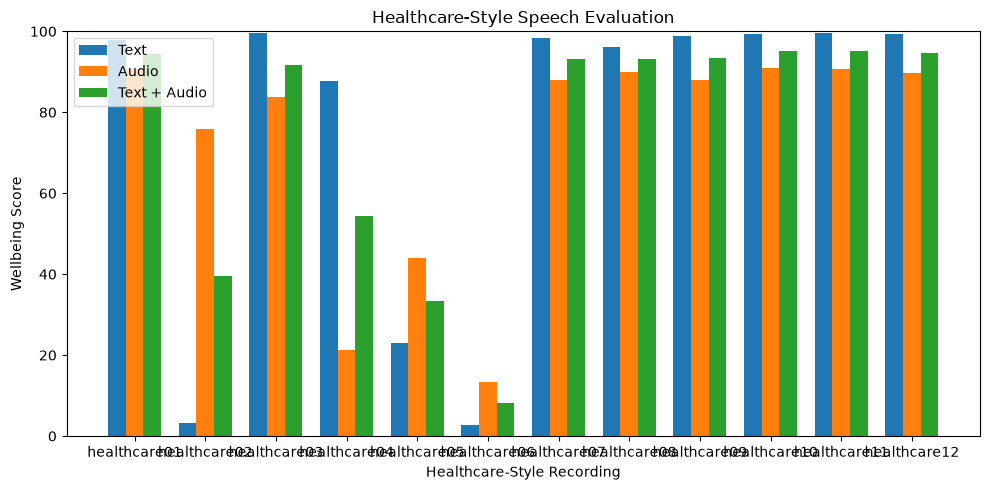

In [36]:
x = np.arange(
    len(healthcare_df)
)

width = 0.25

plt.figure(figsize=(10, 5))

plt.bar(
    x - width,
    healthcare_df["Text wellbeing"],
    width,
    label="Text"
)

plt.bar(
    x,
    healthcare_df["Audio wellbeing"],
    width,
    label="Audio"
)

plt.bar(
    x + width,
    healthcare_df[
        "Text + Audio wellbeing"
    ],
    width,
    label="Text + Audio"
)

plt.xticks(
    x,
    healthcare_df["Clip"]
)

plt.ylabel("Wellbeing Score")
plt.xlabel("Healthcare-Style Recording")
plt.title(
    "Healthcare-Style Speech Evaluation"
)

plt.ylim(0, 100)

plt.legend()
plt.tight_layout()
plt.show()

## 7 Conclusion